## Neural Networks - Deep Learning
**Theodora Tzina - AEM: 10715**
### Exercise 1
#### ***Part C: Multilayer Perceptron***

**Loading and Normalizing CIFAR-10 dataset:**

In [ ]:
import time
from keras import layers, models
from keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.model_selection import train_test_split
from dataProccessing import load_cifar10, get_class_names
from convolutionalNeuralNetwork import cnn_plots, cnn_results, cnn_per_class_accuracy


# Load class names
class_names = get_class_names()

# Load and normalize CIFAR-10 dataset
x_train, y_train, x_test, y_test = load_cifar10()

# Ensure data is in the correct shape for CNN
x_train = x_train.reshape((-1, 32, 32, 3))
x_test = x_test.reshape((-1, 32, 32, 3))

CIFAR-10 Classes
0: airplane
1: automobile
2: bird
3: cat
4: deer
5: dog
6: frog
7: horse
8: ship
9: truck

Loading and Normalizing CIFAR-10
Training data shape: (50000, 32, 32, 3)
Training labels shape: (50000, 1)
Test data shape: (10000, 32, 32, 3)
Test labels shape: (10000, 1)


##### ***MLP Model***

In [ ]:
# MLP for CIFAR‑10
model_mlp = models.Sequential([
    # Input: 32x32x3 -> flatten to 3072
    layers.Input(shape=(32, 32, 3)),
    layers.Flatten(),

    # Block 1
    layers.Dense(512, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.4),

    # Block 2
    layers.Dense(256, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.4),

    # Block 3
    layers.Dense(128, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.4),

    # Output
    layers.Dense(10, activation='softmax')
])

model_mlp.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Same train/val split as before
x_train_mlp, x_val_mlp, y_train_mlp, y_val_mlp = train_test_split(
    x_train, y_train, test_size=0.2, random_state=42, stratify=y_train)

# Data augmentation for MLP
train_datagen_mlp = ImageDataGenerator()
train_datagen_mlp.fit(x_train_mlp)

val_datagen_mlp = ImageDataGenerator()
val_datagen_mlp.fit(x_val_mlp)

# Callbacks for MLP
early_stop_mlp = EarlyStopping(monitor='val_loss', patience=5,
                               restore_best_weights=True, verbose=1)

checkpoint_mlp = ModelCheckpoint('best_model_mlp.keras', monitor='val_loss',
                                 save_best_only=True, verbose=1)

reduce_lr_mlp = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3,
                                  min_lr=1e-6, verbose=1)

# Train MLP
start_time = time.time()
history_mlp = model_mlp.fit(train_datagen_mlp.flow(x_train_mlp, y_train_mlp, batch_size=64), epochs=50, verbose=2, 
                            validation_data=val_datagen_mlp.flow(x_val_mlp, y_val_mlp, batch_size=64),
                            callbacks=[early_stop_mlp, checkpoint_mlp, reduce_lr_mlp])
train_time_mlp = time.time() - start_time

# Evaluate MLP
start_time = time.time()
test_loss_mlp, test_accuracy_mlp = model_mlp.evaluate(x_test, y_test, verbose=2)
test_time_mlp = time.time() - start_time

print(f"MLP training time: {train_time_mlp:.2f} seconds")
print(f"MLP test accuracy: {test_accuracy_mlp * 100:.2f}%")
print(f"MLP test loss: {test_loss_mlp:.4f}")


Epoch 1/50

Epoch 1: val_loss improved from None to 1.90759, saving model to best_model_mlp.keras
625/625 - 33s - 52ms/step - accuracy: 0.2720 - loss: 2.1467 - val_accuracy: 0.3181 - val_loss: 1.9076 - learning_rate: 0.0010
Epoch 2/50

Epoch 2: val_loss improved from 1.90759 to 1.73168, saving model to best_model_mlp.keras
625/625 - 13s - 21ms/step - accuracy: 0.3442 - loss: 1.8237 - val_accuracy: 0.3893 - val_loss: 1.7317 - learning_rate: 0.0010
Epoch 3/50

Epoch 3: val_loss improved from 1.73168 to 1.69386, saving model to best_model_mlp.keras
625/625 - 13s - 21ms/step - accuracy: 0.3668 - loss: 1.7587 - val_accuracy: 0.3963 - val_loss: 1.6939 - learning_rate: 0.0010
Epoch 4/50

Epoch 4: val_loss did not improve from 1.69386
625/625 - 10s - 17ms/step - accuracy: 0.3673 - loss: 1.7553 - val_accuracy: 0.3479 - val_loss: 1.7610 - learning_rate: 0.0010
Epoch 5/50

Epoch 5: val_loss did not improve from 1.69386
625/625 - 11s - 18ms/step - accuracy: 0.3756 - loss: 1.7402 - val_accuracy: 0.

**Plot learning curves and results:**

--> Borrowing already defined functions from convolutionalNeuralNetwork.py

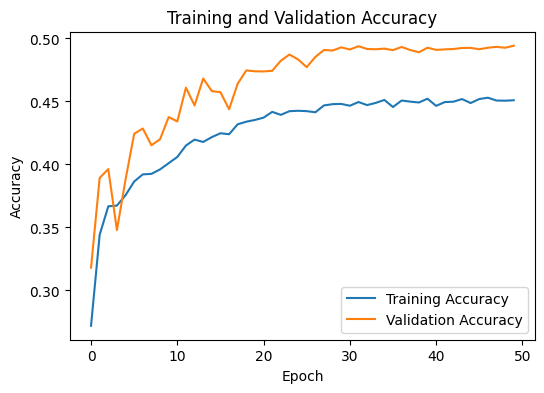

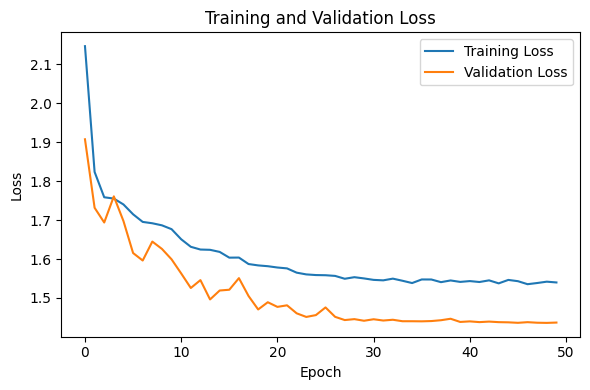

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


=============== Classification Report (CNN) ===============:
              precision    recall  f1-score   support

    airplane       0.56      0.56      0.56      1000
  automobile       0.62      0.62      0.62      1000
        bird       0.35      0.31      0.33      1000
         cat       0.36      0.29      0.32      1000
        deer       0.43      0.44      0.44      1000
         dog       0.46      0.32      0.38      1000
        frog       0.44      0.62      0.52      1000
       horse       0.53      0.58      0.55      1000
        ship       0.58      0.68      0.63      1000
       truck       0.57      0.52      0.54      1000

    accuracy                           0.49     10000
   macro avg       0.49      0.49      0.49     10000
weighted avg       0.49      0.49      0.49     10000



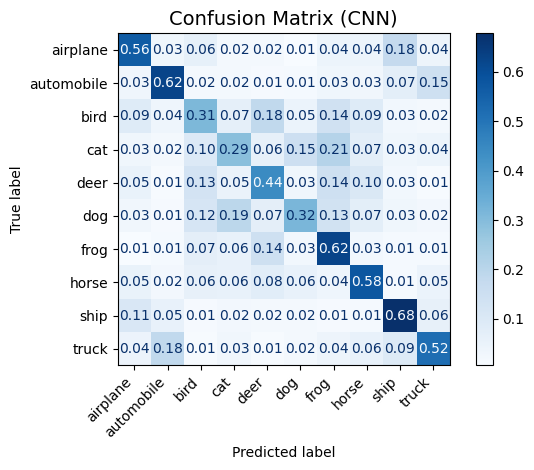

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


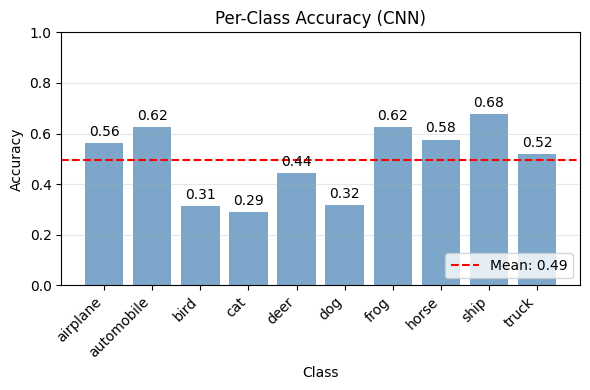

In [ ]:
# Visualizations and detailed results for MLP
cnn_plots(history_mlp)
cnn_results(model_mlp, x_test, y_test, class_names)
cnn_per_class_accuracy(model_mlp, x_test, y_test, class_names)